# freeCAM PI-atm

This notebook follows the same object-oriented UI as FreeCESM. Machine paths, run-directory preparation, PBS submission, `mpiexec`, and the persistent socket are implementation details hidden by `freecam.Driver`.

In [1]:
%load_ext autoreload
%autoreload 2

import freecam as fc
import numpy as np

## 1. Create one model

Constructing the driver is cheap and does not submit a job. The first live-state operation lazily prepares a private run directory, submits one cpudev job when needed, and starts the persistent 512-rank CAM session.

In [2]:
driver = fc.Driver(case='PI-atm', nsteps=2)
print(driver.case)
print('50-step validation:', driver.validation.get('bfb', 'see validation record'))

PI-atm: ne16 CAM5 with SE dynamics, 512 MPI ranks, NO_LEAP calendar
50-step validation: True


PI-CAM Notebook worker submitted as 7088980.desched1; waiting for 512 ranks ...
rank=0   step=0   date=10101   T_mean=245.12 K   u_mean=3.69 m/s   v_mean=-0.60 m/s   q_mean=2.872 g/kg
persistent job: managed by Driver
run directory: /glade/derecho/scratch/ruitong/freeCAM/PI-cam/notebook-20260811-004243-86849f5a/run


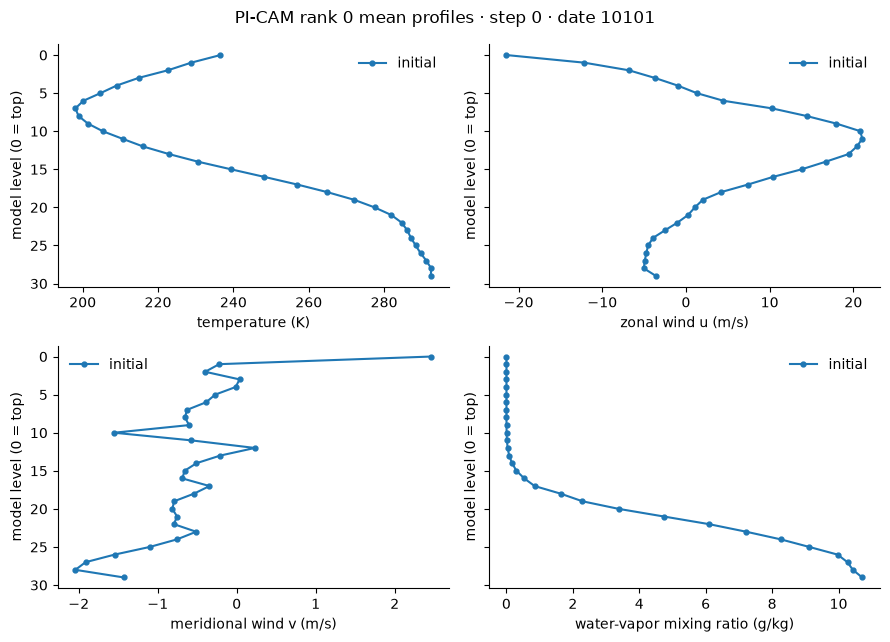

In [3]:
fig, axes = driver.cam.state.plot(rank=0, label='initial')
print(driver.cam.state.summary(rank=0))
print('persistent job:', driver.cam.status.get('job_id', 'managed by Driver'))
print('run directory:', driver.run_dir)

## 2. Inspect and run the Python-owned workflow

The workflow is a live view of the current phase/process order. `execute()` runs complete CAM steps and returns the actual worker-side action trace.

In [4]:
driver.cam.workflow

#,phase,process,native operation,kind
0,coupling,boundary_import,boundary_import,boundary
1,cam_run2,prepare,prepare,control
2,cam_run2,surface_fluxes_and_emissions,chem_emissions,scheme
3,cam_run2,tracers_and_chemistry,tracers_chemistry,scheme
4,cam_run2,tracer_tendencies_leaf,leaf_tracers_timestep_tend,scheme
5,cam_run2,age_of_air_tendencies_leaf,leaf_aoa_tracers_timestep_tend,scheme
6,cam_run2,chemistry_tendencies_leaf,leaf_chem_timestep_tend,scheme
7,cam_run2,vertical_diffusion,vertical_diffusion_tend,scheme
8,cam_run2,rayleigh_friction,rayleigh_friction_tend,scheme
9,cam_run2,aerosol_dry_deposition,aero_model_drydep,scheme


In [5]:
trace = driver.execute(verbose=False)
print(f'executed {len(trace)} actions across {driver.nsteps} complete steps')
print('first:', trace[0]['phase'], trace[0]['name'])
print('last: ', trace[-1]['phase'], trace[-1]['name'])

for axis, variable in zip(axes.flat, ('T', 'u', 'v', 'q')):
    driver.cam.state.plot_profile(
        variable, rank=0, ax=axis, color='tab:orange', label='after 2 steps'
    )
print(driver.cam.state.summary(rank=0))

executed 66 actions across 2 complete steps
first: coupling boundary_import
last:  coupling boundary_export
rank=0   step=2   date=10101   T_mean=245.28 K   u_mean=3.55 m/s   v_mean=-1.07 m/s   q_mean=2.876 g/kg


## 3. Add a variable and a Python physics process

Attribute assignment is declarative: every MPI rank resolves the named dimensions against its local grid, allocates a Fortran-contiguous NumPy array, and registers it in that rank's StatePool. A `Physics` object can then be inserted directly into the live workflow.

In [6]:
driver.cam.state.experiment_tracer = fc.Variable(
    dims=('pcols', 'pver', 'chunks'),
    units='kg kg-1',
    initial=0.0,
    aliases=('tracer',),
    standard_name='experiment_tracer',
)

class NotebookTracer(fc.Physics):
    name = 'notebook_tracer_source'
    phase = 'cam_run1'
    after = 'dadadj'
    writes = ('tracer',)

    def tendency(self, fields, context):
        fields['tracer'][...] += 1.0e-6 * context.timestep_seconds

tracer_process = driver.cam.workflow.insert(NotebookTracer())
driver.cam.workflow

#,phase,process,native operation,kind
0,coupling,boundary_import,boundary_import,boundary
1,cam_run2,prepare,prepare,control
2,cam_run2,surface_fluxes_and_emissions,chem_emissions,scheme
3,cam_run2,tracers_and_chemistry,tracers_chemistry,scheme
4,cam_run2,tracer_tendencies_leaf,leaf_tracers_timestep_tend,scheme
5,cam_run2,age_of_air_tendencies_leaf,leaf_aoa_tracers_timestep_tend,scheme
6,cam_run2,chemistry_tendencies_leaf,leaf_chem_timestep_tend,scheme
7,cam_run2,vertical_diffusion,vertical_diffusion_tend,scheme
8,cam_run2,rayleigh_friction,rayleigh_friction_tend,scheme
9,cam_run2,aerosol_dry_deposition,aero_model_drydep,scheme


In [7]:
# Run only this process; the model clock does not advance.
tracer_process.run()
print(driver.cam.state.experiment_tracer.stats(rank='global'))

# The same object controls its placement and on/off state.
tracer_process.move(before='deep_convection')
tracer_process.disable()
tracer_process.enable()

{'rank': 'global', 'count': 491520, 'min': 0.0018, 'max': 0.0018, 'mean': 0.0017999999999999997}


{'name': 'notebook_tracer_source', 'phase': 'cam_run1', 'enabled': True}

## 4. Load an original Fortran process at runtime

The same state syntax defines its inputs. freeCAM generates the `bind(C)` adapter, compiles the device `.so`, loads it on every rank, and inserts the process into the workflow.

In [8]:
driver.cam.state.runtime_temperature = fc.Variable(
    dims=('nphys_local', 'pver'),
    units='K',
    initial=240.0,
    standard_name='runtime_plugin_temperature',
)
driver.cam.state.runtime_temperature_increment = fc.Variable(
    dims=(),
    units='K',
    initial=1.5,
    writable=False,
    standard_name='runtime_plugin_temperature_increment',
)

fortran_process = driver.cam.physics.install_fortran(
    driver.repo / 'examples/plugins/runtime_temperature_offset/device.yaml',
    project_root=driver.repo,
    process='runtime_temperature_offset',
    phase='cam_run1',
    after='dadadj',
    unsafe=True,
)
fortran_process.run()
driver.cam.state.runtime_temperature.stats(rank='global')

{'rank': 'global', 'count': 414780, 'min': 241.5, 'max': 241.5, 'mean': 241.5}

## 5. Every supported physics interface

`driver.cam.physics` is a flat API: original module/subroutine nesting is metadata, not part of the user path. The active PI-atm call graph contains 372 reachable procedures, but these are not all physical processes: deterministic signature rules classify 276 state-updating routines as processes, 95 read-only math/lookup routines as helpers, and one routine as lifecycle. The 276 source processes merge with 36 live workflow boundaries into 298 unique handles. Every handle states whether it is independently runnable; catalog-only processes fail explicitly until their StatePool/context bindings are admitted.

In [9]:
physics = driver.cam.physics
display(physics)
print('coverage:', physics.coverage)
print('runnable cam_run1:', [
    process.name for process in physics.by_phase('cam_run1') if process.runnable
])

# Access by the original Fortran operation or by its readable workflow alias.
dadadj = physics.dadadj
assert dadadj.operation == physics.dry_adjustment.operation == 'dadadj'
dadadj_trace = dadadj.run()
print('dadadj:', dadadj_trace)

# Scientifically named source kernels use the same flat namespace.
cloud_ice = physics.cloud_fraction_fice
evaporation = physics.zm_conv_evap
print('cloud_fraction_fice:', cloud_ice.runnable, cloud_ice.metadata)
print('zm_conv_evap:', evaporation.runnable, evaporation.parent_processes)

# Each process has its own control handle; restore the original state here.
physics.radiation.disable()
physics.radiation.enable()

Phase,Python API,Original routine,Level,Capability
cam_run2,surface_fluxes_and_emissions,chem_emissions,stage,enabled
cam_run2,tracers_and_chemistry,tracers_chemistry,stage,enabled
cam_run2,tracer_tendencies_leaf,leaf_tracers_timestep_tend,leaf,disabled
cam_run2,age_of_air_tendencies_leaf,leaf_aoa_tracers_timestep_tend,leaf,disabled
cam_run2,chemistry_tendencies_leaf,leaf_chem_timestep_tend,leaf,disabled
cam_run2,vertical_diffusion,vertical_diffusion_tend,stage,enabled
cam_run2,rayleigh_friction,rayleigh_friction_tend,stage,enabled
cam_run2,aerosol_dry_deposition,aero_model_drydep,stage,enabled
cam_run2,aerosol_dry_deposition_leaf,leaf_aero_model_drydep,leaf,disabled
cam_run2,carma_aerosol_tendencies_leaf,leaf_carma_timestep_tend,leaf,disabled


coverage: {'interfaces': 300, 'runnable': 38, 'catalog_only': 262, 'enabled': 23, 'disabled': 15, 'leaf': 15, 'stage': 23, 'source_reachable': 372, 'source_catalog': 371, 'physical_processes': 276, 'helper_routines': 95, 'runtime_overlap': 14, 'excluded_lifecycle': 1}
runnable cam_run1: ['state_initialize', 'energy_fixer', 'dry_adjustment', 'runtime_temperature_offset', 'notebook_tracer_source', 'deep_convection', 'shallow_convection', 'sea_salt_rebin', 'cloud_macro_microphysics', 'wet_deposition', 'modal_aerosol_preparation_leaf', 'aerosol_wet_deposition_leaf', 'carma_wet_deposition_leaf', 'convective_tracer_transport_leaf', 'diagnostics', 'state_and_convection_diagnostics_leaf', 'cloud_diagnostics_leaf', 'radiation', 'state_export', 'tropopause_leaf', 'state_export_leaf', 'export_diagnostics_leaf']
dadadj: {'sequence': 105, 'coupling_step': 3, 'model_step': 2, 'phase': 'direct_kernel', 'name': 'dadadj', 'operation': 'dadadj', 'native_id': None}
cloud_fraction_fice: False {'phase': 'c

{'name': 'radiation', 'phase': 'cam_run1', 'enabled': True}

## 6. Call an original process with Python objects

Calling the process infers `ncol` and the model temperature automatically. The framework internally binds those inputs to StatePool, allocates `fice` and `fsnow`, calls the original Fortran routine, and returns named output fields. Pass `t=driver.cam.state.T` only when you want to override the inferred binding explicitly. This isolated call does not insert a duplicate call into the complete timestep.

In [10]:
cloud_result = driver.cam.physics.cloud_fraction_fice()

# Named outputs are ordinary distributed StatePool fields.
print(cloud_result.fice.stats(rank='global'))
print(cloud_result.fsnow.stats(rank='global'))
print(cloud_result.trace)

{'rank': 'global', 'count': 491520, 'min': 0.0, 'max': 1.0, 'mean': 0.4905054828066816}
{'rank': 'global', 'count': 491520, 'min': 0.0, 'max': 1.0, 'mean': 0.6175745256382227}
{'sequence': 106, 'coupling_step': 3, 'model_step': 2, 'phase': 'promoted_process', 'name': 'cloud_fraction_fice', 'operation': 'cloud_fraction_fice', 'native_id': None}


## 7. Remove runtime extensions and close the model

Processes must be removed before deleting fields they use. `driver.close()` finalizes CAM and releases the persistent PBS/MPI session.

In [11]:
cloud_result.remove()
tracer_process.remove()
fortran_process.remove()

del driver.cam.state.experiment_tracer
del driver.cam.state.runtime_temperature
del driver.cam.state.runtime_temperature_increment

driver.close()
print('closed:', not driver.running)

closed: True
